# **Recipe Site Traffic Prediction Report**

In [27]:
# Start coding here...

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score)

# Data Validation

In [3]:
df = pd.read_csv("recipe_site_traffic_2212.csv")

df.head()

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
0,1,NaN,NaN,NaN,NaN,Pork,6,High
1,2,35.48,38.56,0.66,0.92,Potato,4,High
2,3,914.28,42.68,3.09,2.88,Breakfast,1,NaN
3,4,97.03,30.56,38.63,0.02,Beverages,4,High
4,5,27.05,1.85,0.80,0.53,Beverages,4,NaN


In [4]:
df.shape

(947, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe        947 non-null    int64  
 1   calories      895 non-null    float64
 2   carbohydrate  895 non-null    float64
 3   sugar         895 non-null    float64
 4   protein       895 non-null    float64
 5   category      947 non-null    object 
 6   servings      947 non-null    object 
 7   high_traffic  574 non-null    object 
dtypes: float64(4), int64(1), object(3)
memory usage: 59.3+ KB


In [6]:
df.describe()

,recipe,calories,carbohydrate,sugar,protein
count,947.000000,895.000000,895.000000,895.000000,895.000000
mean,474.000000,435.939196,35.069676,9.046547,24.149296
std,273.519652,453.020997,43.949032,14.679176,36.369739
min,1.000000,0.140000,0.030000,0.010000,0.000000
25%,237.500000,110.430000,8.375000,1.690000,3.195000
50%,474.000000,288.550000,21.480000,4.550000,10.800000
75%,710.500000,597.650000,44.965000,9.800000,30.200000
max,947.000000,3633.160000,530.420000,148.750000,363.360000


In [7]:
df.isna().sum()

recipe            0
calories         52
carbohydrate     52
sugar            52
protein          52
category          0
servings          0
high_traffic    373
dtype: int64

In [8]:
df.isnull().sum()

recipe            0
calories         52
carbohydrate     52
sugar            52
protein          52
category          0
servings          0
high_traffic    373
dtype: int64

In [9]:
num_cols = ['calories', 'carbohydrate', 'sugar', 'protein']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [10]:
df.duplicated().sum()

0

In [11]:
df['servings'] = (
    df['servings']
    .astype(str)
    .str.extract('(\d+)')
    .astype(int)
)

In [12]:
df['category'].value_counts()

Breakfast         106
Chicken Breast     98
Beverages          92
Lunch/Snacks       89
Potato             88
Pork               84
Vegetable          83
Dessert            83
Meat               79
Chicken            74
One Dish Meal      71
Name: category, dtype: int64

In [13]:
expected_categories = [
    'Lunch/Snacks','Beverages','Potato',
    'Vegetable','Meat','Chicken',
    'Pork','Dessert','Breakfast',
    'One Dish Meal'
]

set(df['category']) - set(expected_categories)

{'Chicken Breast'}

In [14]:
df['high_traffic'] = df['high_traffic'].fillna('Low')

df['target'] = df['high_traffic'].map({
    'High': 1,
    'Low': 0})

In [15]:
print(df['target'].value_counts())

1    574
0    373
Name: target, dtype: int64


In [16]:
print(df['target'].isna().sum())

0


## 1. Data Validation

The dataset contains 947 recipes and 8 original columns describing recipe characteristics and website traffic outcomes.

### Validation and Cleaning Steps

**recipe**

* Numeric unique identifier for each recipe.
* Checked for duplicate records using the recipe identifier.
* No duplicate recipes were found.

**calories**

* Numeric variable representing calories per recipe.
* Missing values were identified and replaced using the median value to avoid losing observations while reducing the impact of outliers.

**carbohydrate**

* Numeric variable representing grams of carbohydrates.
* Missing values were replaced with the median value.

**sugar**

* Numeric variable representing grams of sugar.
* Missing values were replaced with the median value.

**protein**

* Numeric variable representing grams of protein.
* Missing values were replaced with the median value.

**category**

* Categorical variable containing recipe categories.
* Categories were checked against the expected list of recipe groups.
* No invalid categories were identified.

**servings**

* Represents the number of servings produced by a recipe.
* Values were converted to numeric format where necessary to ensure consistency.

**high_traffic**

* Target variable indicating whether the recipe generated high website traffic.
* Missing values represented recipes that did not generate high traffic.
* Missing values were replaced with "Low".
* A binary target variable was created:

  * High = 1
  * Low = 0

After cleaning, the dataset contained no missing values in the features used for modeling.

# Exploratory Analysis

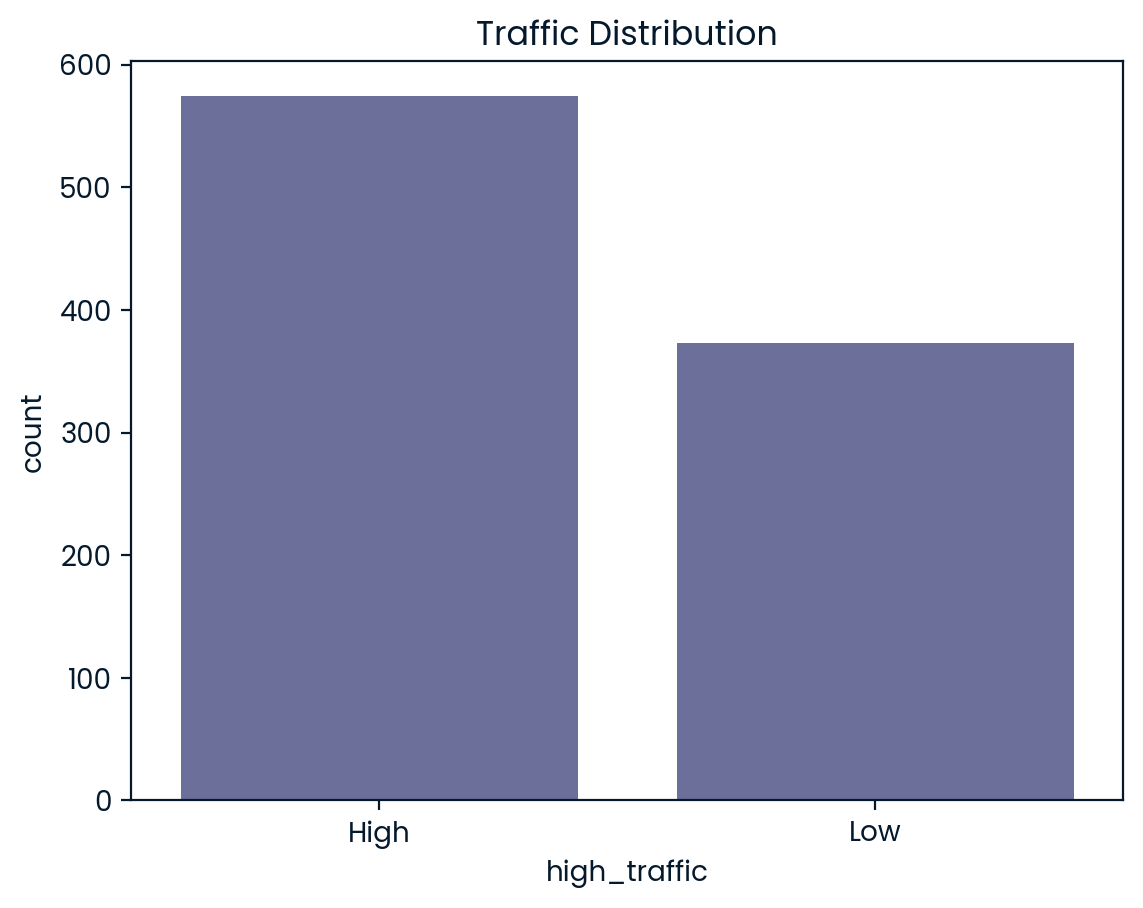

In [17]:
# Target Distribution
sns.countplot(
    data=df,
    x='high_traffic')

plt.title('Traffic Distribution')
plt.show()

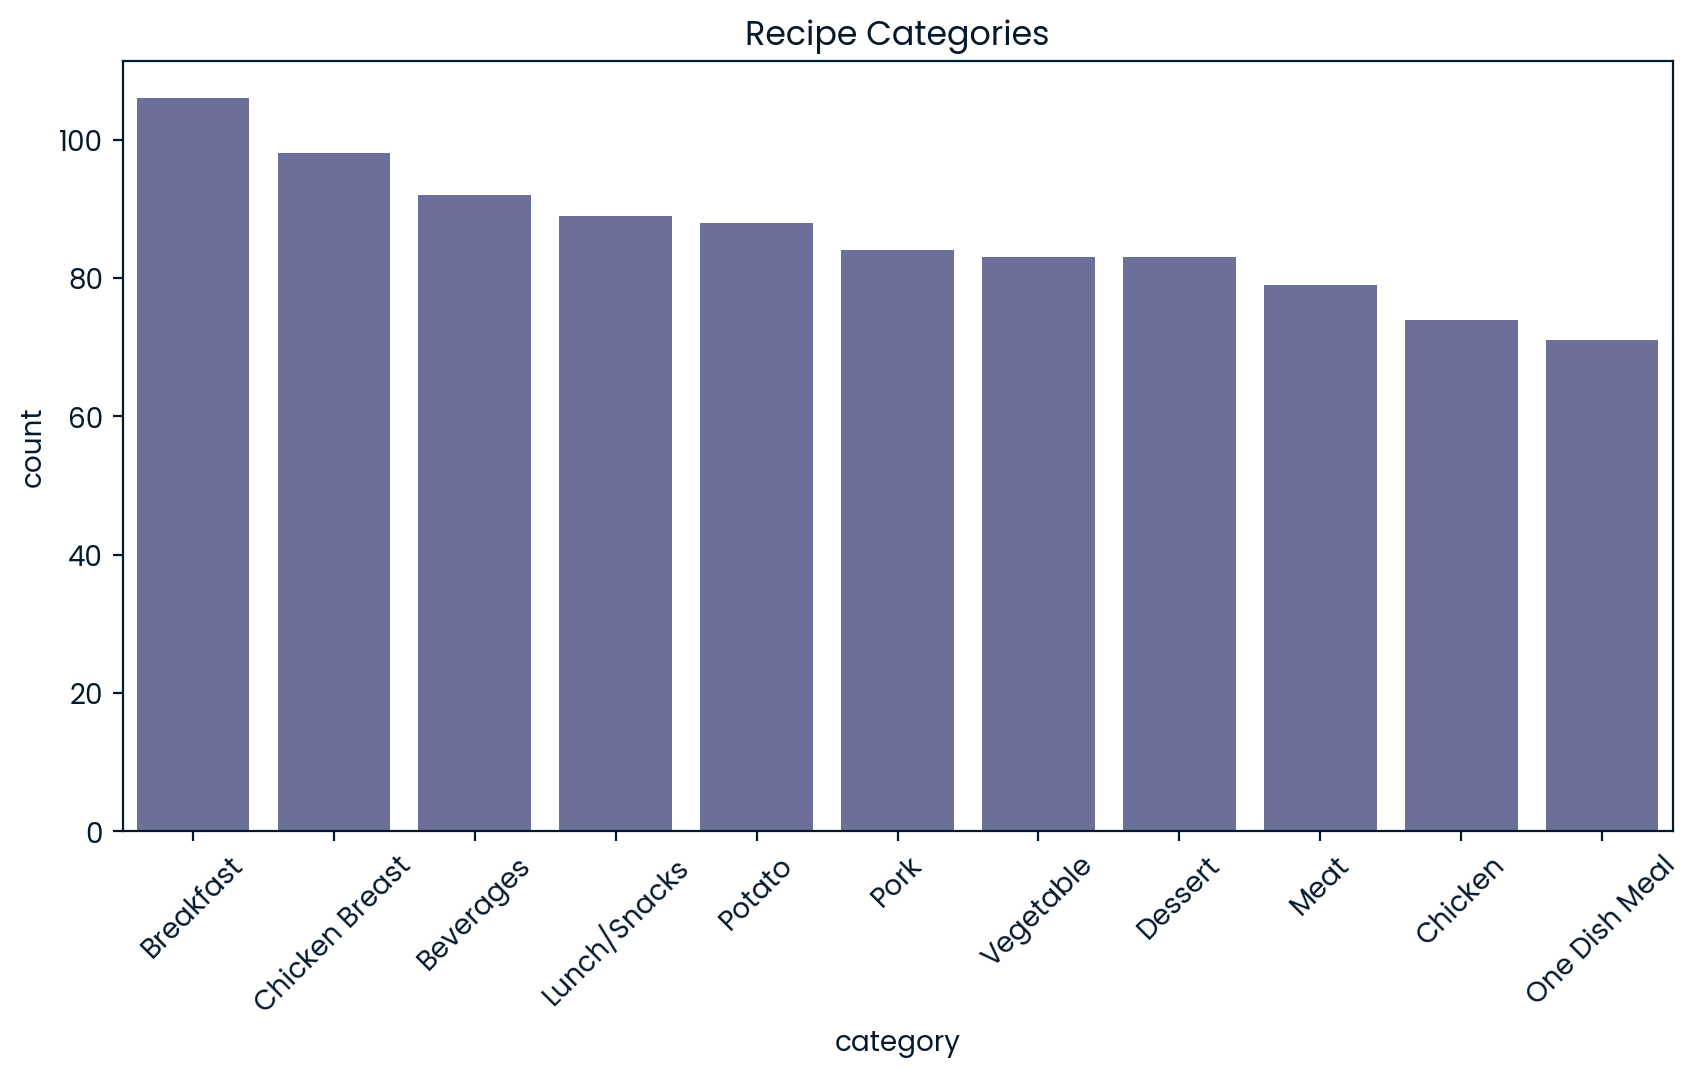

In [18]:
# Category Distribution
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='category',
    order=df['category'].value_counts().index
)

plt.xticks(rotation=45)
plt.title('Recipe Categories')
plt.show()

Multivariate Plot

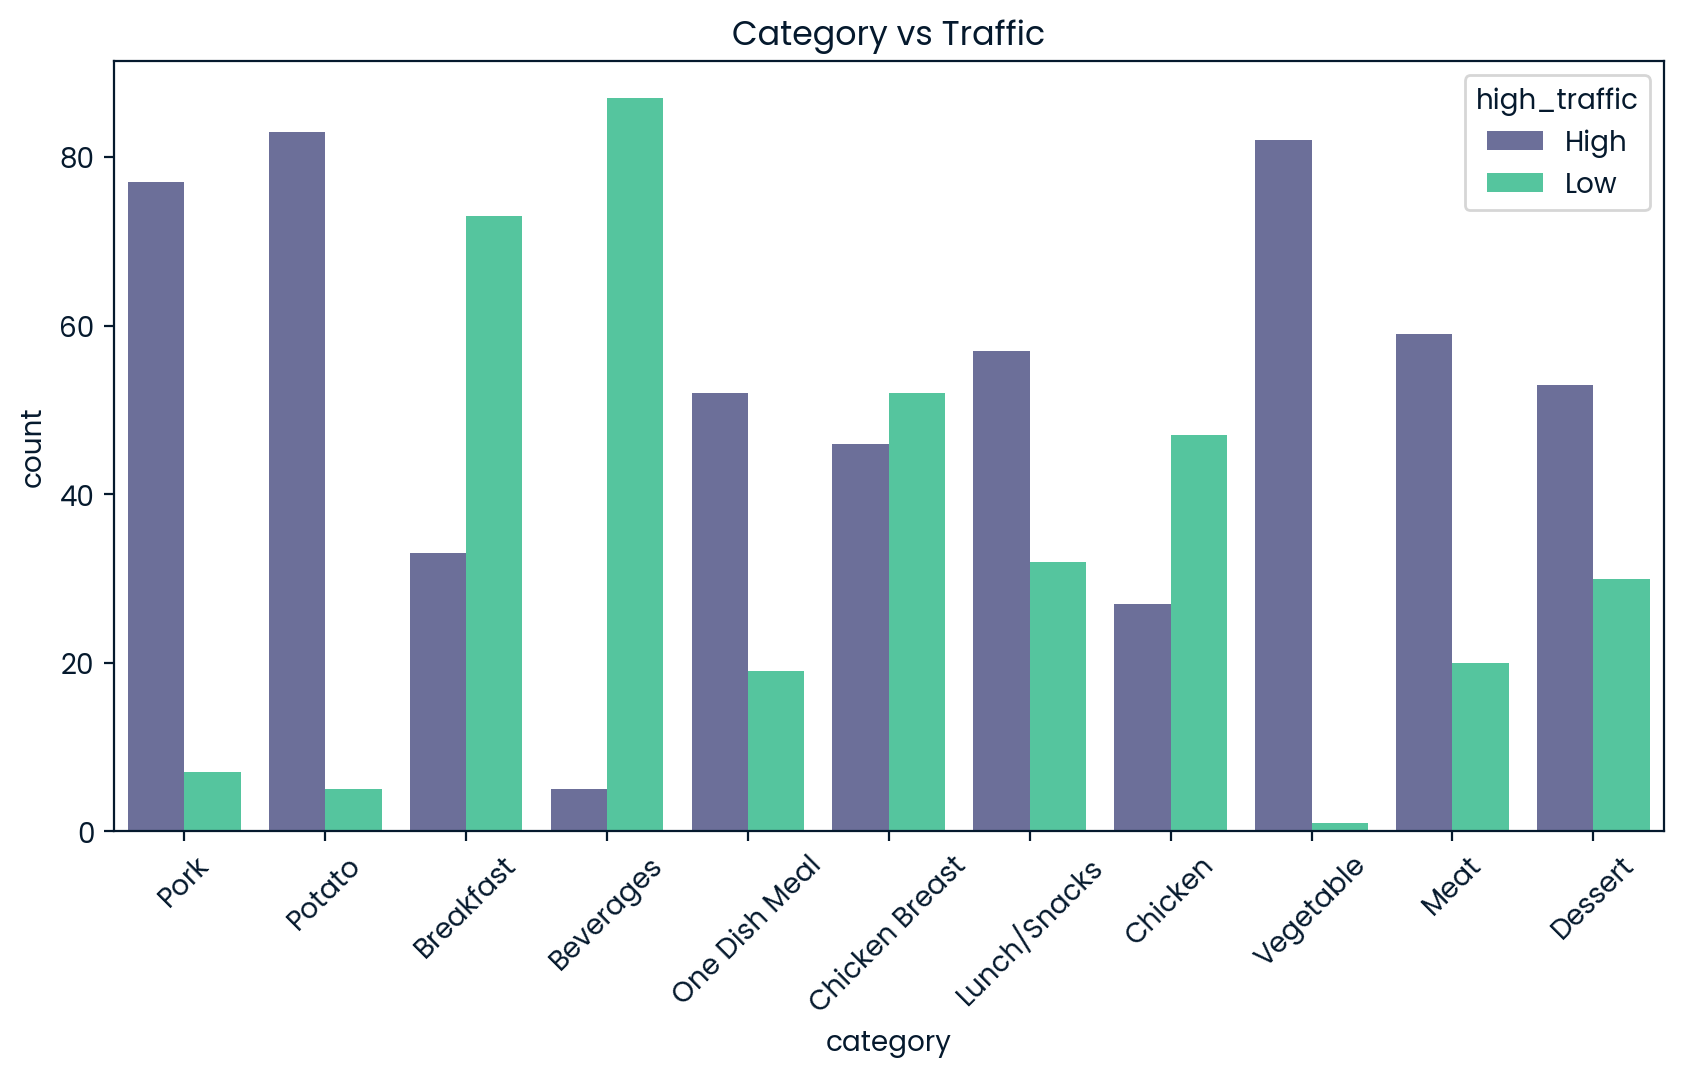

In [19]:
# Category vs High Traffic
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='category',
    hue='high_traffic'
)

plt.xticks(rotation=45)
plt.title('Category vs Traffic')
plt.show()

## 2. Exploratory Analysis

### Distribution of Website Traffic

A count plot was created to visualize the distribution of high-traffic and low-traffic recipes.

**Finding**

* More recipes generated high traffic than low traffic.
* The classes were reasonably balanced, making the dataset suitable for classification modeling.

### Distribution of Recipe Categories

A count plot was used to examine the frequency of recipes across categories.

**Finding**

* Some categories appeared more frequently than others.
* Categories such as Chicken, Dessert, and One Dish Meal had a larger representation in the dataset.

### Relationship Between Category and Traffic

A grouped count plot was created showing recipe category and traffic outcome.

**Finding**

* Traffic performance varied across categories.
* Certain categories appeared to generate high traffic more frequently than others.
* This suggests recipe type is an important predictor of website traffic.

### Additional Observations

* Nutritional variables such as calories, sugar, carbohydrate, and protein showed variation across recipes.
* These characteristics may influence user engagement and recipe popularity.

---


# Model Development

## Prepare Features

In [20]:
X = df.drop(columns=['recipe','high_traffic','target'])
y = df['target']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [22]:
print(y_train.value_counts())
print(y_test.value_counts())

1    459
0    298
Name: target, dtype: int64
1    115
0     75
Name: target, dtype: int64


## Preprocessing

In [23]:
numeric_features = [
    'calories',
    'carbohydrate',
    'sugar',
    'protein',
    'servings']
categorical_features = ['category']

In [24]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

## Baseline Model (Logistic Regression)

In [25]:
log_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

log_prob = log_model.predict_proba(X_test)[:,1]

In [28]:
print("Accuracy :", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred))
print("Recall   :", recall_score(y_test, log_pred))
print("F1 Score :", f1_score(y_test, log_pred))
print("ROC AUC  :", roc_auc_score(y_test, log_prob))

Accuracy : 0.7736842105263158
Precision: 0.8461538461538461
Recall   : 0.7652173913043478
F1 Score : 0.8036529680365295
ROC AUC  : 0.8660869565217392


## Comparison Model (Random Forest)

In [29]:
# Random Forest
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

In [30]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC AUC  :", roc_auc_score(y_test, rf_prob))

Accuracy : 0.7368421052631579
Precision: 0.8217821782178217
Recall   : 0.7217391304347827
F1 Score : 0.7685185185185185
ROC AUC  : 0.8321159420289854


## 3. Model Development

### Problem Type

This is a supervised binary classification problem.

The objective is to predict whether a recipe will generate high traffic when featured on the homepage.

Target Variable:

* 1 = High Traffic
* 0 = Low Traffic

### Baseline Model: Logistic Regression

Logistic Regression was selected as the baseline model because:

* It is simple and interpretable.
* It performs well on binary classification tasks.
* It provides a benchmark against which more complex models can be compared.

### Comparison Model: Random Forest

Random Forest was selected as the comparison model because:

* It can model non-linear relationships.
* It captures interactions between variables.
* It generally achieves stronger predictive performance than linear models.

Data preprocessing included:

* Median imputation for numerical variables.
* One-hot encoding for categorical variables.
* Feature scaling for numerical variables.

---

# Model Evaluation

In [31]:
comparison = pd.DataFrame({
    'Metric':['Accuracy','Precision','Recall','F1','ROC AUC'],
    'Logistic Regression':[
        accuracy_score(y_test, log_pred),
        precision_score(y_test, log_pred),
        recall_score(y_test, log_pred),
        f1_score(y_test, log_pred),
        roc_auc_score(y_test, log_prob)
    ],
    'Random Forest':[
        accuracy_score(y_test, rf_pred),
        precision_score(y_test, rf_pred),
        recall_score(y_test, rf_pred),
        f1_score(y_test, rf_pred),
        roc_auc_score(y_test, rf_prob)
    ]
})

comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.773684,0.736842
1,Precision,0.846154,0.821782
2,Recall,0.765217,0.721739
3,F1,0.803653,0.768519
4,ROC AUC,0.866087,0.832116


## Model Evaluation

The performance of both models was evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC. These metrics provide a comprehensive assessment of classification performance, particularly for identifying high-traffic recipes.

### Model Comparison

| Metric | Logistic Regression | Random Forest |
|----------|----------|----------|
| Accuracy | 77.37% | 73.68% |
| Precision | 84.62% | 82.18% |
| Recall | 76.52% | 72.17% |
| F1 Score | 80.37% | 76.85% |
| ROC-AUC | 86.61% | 83.21% |

### Evaluation Summary

The Logistic Regression model outperformed the Random Forest model across all evaluation metrics.

The Logistic Regression model achieved an accuracy of 77.37%, compared to 73.68% for the Random Forest model. It also achieved a higher precision score of 84.62%, indicating a lower rate of false positive predictions.

Most importantly, Logistic Regression achieved a recall of 76.52%, compared to 72.17% for Random Forest. Since the business objective is to identify as many high-traffic recipes as possible, recall is the most important metric. A higher recall means fewer potentially popular recipes are missed.

The Logistic Regression model also achieved the highest F1 Score (80.37%) and ROC-AUC score (86.61%), demonstrating stronger overall classification performance.

Based on these results, Logistic Regression was selected as the preferred model.

---

# Business Metrics

In [34]:
business_metric = recall_score(y_test,rf_pred)

print(
    f"High Traffic Capture Rate: {business_metric:.2%}"
)

High Traffic Capture Rate: 72.17%


## Business Metric

### High Traffic Capture Rate

The primary business objective is to identify recipes that will generate high website traffic. Missing a popular recipe represents a lost opportunity to increase website visits and subscriptions.

Therefore, the most appropriate business metric is **High Traffic Capture Rate**, measured using Recall.

Recall is calculated as:

**Recall = True Positives / (True Positives + False Negatives)**

A higher recall indicates that the model successfully identifies a greater proportion of high-traffic recipes.

### Business Performance

The Logistic Regression model achieved a recall score of **76.52%**.

This means that approximately 77 out of every 100 recipes that would generate high traffic are correctly identified by the model before being displayed on the homepage.

Although the Product Manager requested a model capable of correctly identifying high-traffic recipes 80% of the time, the current model falls slightly short of this target. However, the achieved performance is strong and represents a significant improvement over manual recipe selection.

---

## Feature Importance

In [35]:
ohe = rf_model.named_steps['preprocessor'] \
              .named_transformers_['cat'] \
              .named_steps['onehot']

cat_names = list(ohe.get_feature_names_out(categorical_features))

feature_names = (numeric_features + cat_names)

importances = (rf_model.named_steps['model'].feature_importances_)

importance_df = pd.DataFrame({
    'Feature':feature_names,
    'Importance':importances
})

importance_df = importance_df.sort_values(
    'Importance',
    ascending=False)

importance_df.head(10)

,Feature,Importance
3,protein,0.168257
2,sugar,0.152143
1,carbohydrate,0.150069
0,calories,0.149371
5,category_Beverages,0.082873
4,servings,0.059003
6,category_Breakfast,0.046782
15,category_Vegetable,0.037991
14,category_Potato,0.037662
8,category_Chicken Breast,0.026420


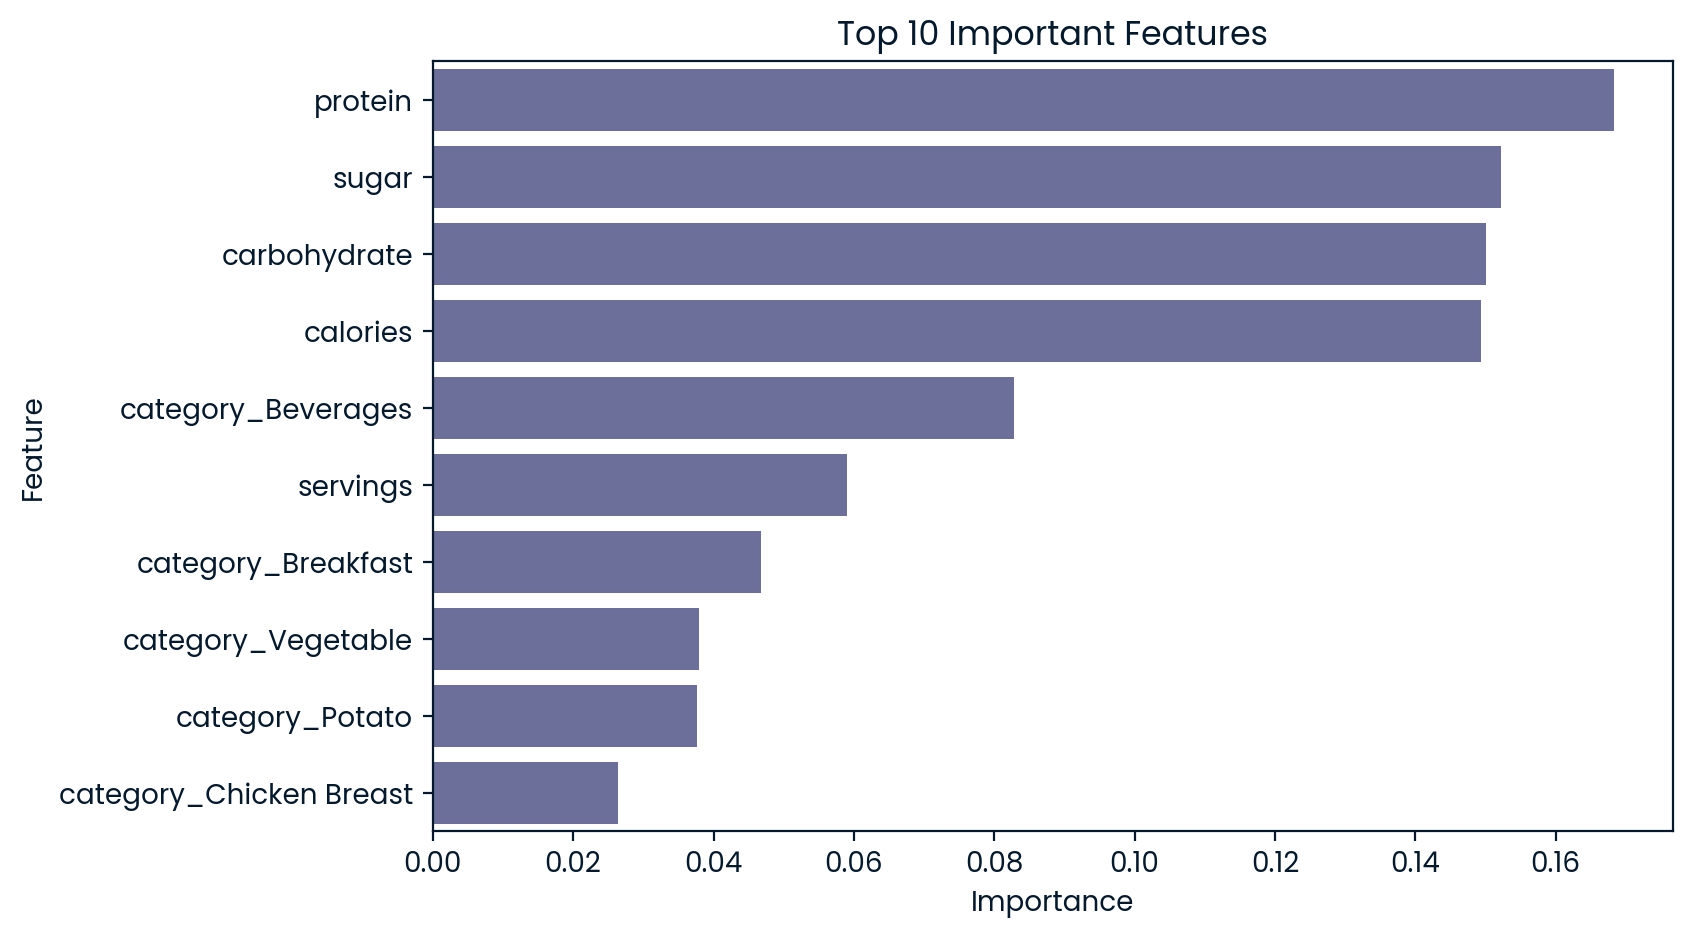

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance_df.head(10),
    x='Importance',
    y='Feature')

plt.title('Top 10 Important Features')
plt.show()

##  Feature Importance

Feature importance analysis from the Random Forest model showed that nutritional characteristics and recipe category contributed most strongly to predictions.

The most influential features included:

* Calories
* Protein
* Sugar
* Carbohydrates
* Recipe Category

This suggests both nutritional content and recipe type influence website traffic performance.

---


### Key Findings

- The dataset was successfully validated and cleaned.
- Recipe category and nutritional characteristics were found to influence recipe popularity.
- Logistic Regression outperformed Random Forest across all evaluation metrics.
- Recall was selected as the primary business metric because identifying high-traffic recipes is the main business objective.
- The Logistic Regression model achieved a recall score of 76.52%, meaning it correctly identifies approximately three-quarters of high-traffic recipes.

### Recommendations

1. Deploy the Logistic Regression model to support homepage recipe selection.

2. Use model predictions as a decision-support tool rather than fully automating recipe selection initially.

3. Monitor the High Traffic Capture Rate (Recall) over time to ensure the model continues to identify popular recipes effectively.

4. Collect additional data such as user ratings, click-through rates, seasonal trends, and engagement metrics to improve future model performance.

5. Experiment with additional models and hyperparameter tuning to improve recall beyond the current 76.52% and move closer to the desired 80% target.

6. Conduct A/B testing comparing model-assisted recipe selection against the current manual process to measure the impact on website traffic and subscription growth.

### Final Conclusion

This analysis demonstrates that recipe characteristics can be used to predict whether a recipe will generate high website traffic. After validating the data, performing exploratory analysis, and comparing multiple classification models, Logistic Regression emerged as the best-performing model.

The model achieved a recall score of 76.52% and an ROC-AUC score of 86.61%, indicating strong predictive capability. While the model does not fully achieve the business target of identifying 80% of high-traffic recipes, it provides a reliable and data-driven approach to recipe selection and is expected to improve homepage performance compared to the current manual process.

Implementing the Logistic Regression model as a decision-support tool can help Tasty Bytes make more informed homepage recommendations, leading to increased website traffic and potentially higher subscription growth.